# JW $Z_4^{TF}$ system

Created: 01-09-2026

Objectives:
* Take states from [this notebook](../truncating_reduced_density_matrices/mps_optimisation_jw_z_4_tf_system.ipynb), and apply disentangling projectors to see if we get better (or the same) results.

# Imports

In [1]:
import numpy as np

In [2]:
import jax
jax.config.update('jax_platform_name', 'cpu')

import jax.numpy as jnp

In [3]:
import matplotlib.pyplot as plt

In [4]:
from tqdm import tqdm

In [5]:
from functools import reduce
from operator import mul

In [6]:
import quimb.tensor as qtn
import quimb as qu

In [7]:
from scipy.stats import ortho_group

In [8]:
from collections import Counter

In [9]:
import pandas as pd

In [10]:
from time import time

In [11]:
from humanize import naturalsize

# Definitions
## Construct cluster state

In [12]:
np_up_X_state = 1/(np.sqrt(2))*np.array([1,1])

In [13]:
qu_up_X_state = qtn.Tensor(
    data=np_up_X_state,
    inds=('k',),
    tags='prod'
)

In [14]:
np_CZ = np.diag([1,1,1,-1])

In [15]:
np_CZ = np_CZ.reshape((2,)*4)

In [16]:
qu_CZ = qtn.Tensor(
    data=np_CZ,
    inds=('k1', 'k2', 'b1', 'b2'),
    tags='CZ'
)

In [17]:
np_hadamard = np.pow(2, -1/2)*np.array([
    [1,1],
    [1,-1]
])

In [18]:
qu_hadamard = qtn.Tensor(data=np_hadamard, inds=('k', 'b'), tags='Had')

In [19]:
def get_cluster_state_qu_tensor_network(num_sites):
    assert (num_sites%2) == 0

    product_state_tensors = [
        qu_up_X_state.reindex({'k': f'kc_1_{i}'})
        for i in range(num_sites)
    ]

    first_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_1_{i}',
            'b2': f'kc_1_{i+1}',
            'k1': f'kc_2_{i}',
            'k2': f'kc_2_{i+1}'
        })
        for i in range(0, num_sites, 2)
    ]


    second_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_2_{i}',
            'b2': f'kc_2_{(i+1)%num_sites}',
            'k1': f'kh_{i}',
            'k2': f'k{(i+1)%num_sites}'
        })
        for i in range(1, num_sites+1, 2)
    ]

    hadamard_layer = [
        qu_hadamard.reindex({
            'b': f'kh_{i}',
            'k': f'k{i}'
        })
        for i in range(1, num_sites, 2)
    ]
    all_tensors = (
        product_state_tensors
        + first_layer_circuit_tensors
        + second_layer_circuit_tensors
        + hadamard_layer
    )

    out = qtn.TensorNetwork(all_tensors, virtual=True)
    out.mangle_inner_()

    return out

## Construct product state

In [20]:
np_up_X_state = 1/(np.sqrt(2))*np.array([1,1])

In [21]:
np_up_Z_state = np.array([1,0])

In [22]:
qu_up_Z_state = qtn.Tensor(
    data=np_up_Z_state,
    inds=('k',),
    tags='prod'
)

In [23]:
alternating_states = [
    qu_up_X_state,
    qu_up_Z_state
]

def get_product_qu_tensor_network(num_sites):
    assert (num_sites%2) == 0

    product_state_tensors = [
        alternating_states[i%2].reindex({'k': f'k{i}'})
        for i in range(num_sites)
    ]

    out = qtn.TensorNetwork(
        product_state_tensors,
        virtual=True
    )
    out.mangle_inner_()

    return out

## Symmetries

In [24]:
def multikron(arrays):
    return reduce(np.kron, arrays)

In [25]:
np_I = np.array([
    [1,0],
    [0,1]
])

np_X = np.array([
    [0,1],
    [1,0]
])

np_Y = np.array([
    [0,-1j],
    [1j,0]
])

np_Z = np.array([
    [1,0],
    [0,-1]
])

In [26]:
qu_I = qtn.Tensor(
    np_I,
    inds=['k', 'b'],
    tags='X'
)

qu_X = qtn.Tensor(
    np_X,
    inds=['k', 'b'],
    tags='X'
)

qu_Y = qtn.Tensor(
    np_Y,
    inds=['k', 'b'],
    tags='Y'
)

qu_Z = qtn.Tensor(
    np_Z,
    inds=['k', 'b'],
    tags='Z'
)

In [27]:
def get_multisite_qu_X(num_sites):
    np_many_X = multikron([np_X]*num_sites)

    out = qtn.Tensor(
        np_many_X,
        inds=['k', 'b'],
        tags='mulit_site_X',
    )

    return out

In [28]:
def get_multisite_qu_I(num_sites):
    np_many_I = multikron([np_I]*num_sites)

    out = qtn.Tensor(
        np_many_I,
        inds=['k', 'b'],
        tags='mulit_site_I',
    )

    return out

In [29]:
qu_spin_fermion_fp = (
    qu_I.reindex({'k': 'ks', 'b': 'bs'})
    & qu_Z.reindex({'k': 'kf', 'b': 'bf'})
).contract()

qu_unit_cell_fp = qu_spin_fermion_fp.fuse({
    'k': ['ks', 'kf'],
    'b': ['bs', 'bf']
})

In [30]:
"""
def get_multisite_qu_fp(num_sites):
    assert (num_sites%2)==0

    num_unit_cells = (num_sites//2)

    np
"""

'\ndef get_multisite_qu_fp(num_sites):\n    assert (num_sites%2)==0\n\n    num_unit_cells = (num_sites//2)\n\n    np\n'

Decompose T symmetry as $MK$:

In [31]:
np_00 = np.array([[1,0], [0,0]])
np_11 = np.array([[0,0], [0,1]])

In [32]:
def tensor_product_operators(op_1, op_2):
    out = (
        op_1[..., np.newaxis, np.newaxis]
        *op_2[np.newaxis, np.newaxis, ...]
    )

    return out

In [33]:
np_M = (
    tensor_product_operators(np_X, np_00)
    + tensor_product_operators(np_Y, np_11)
)

In [34]:
qu_M = qtn.Tensor(
    np_M,
    inds=['ks', 'bs', 'kf', 'bf']
)

In [35]:
np_M_reindexed = (
    qu_M
    .fuse({
        'k': ['ks', 'kf'],
        'b': ['bs', 'bf']
    })
    .transpose('k', 'b')
    .data
)

## Extracting projectors

In [36]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [37]:
def lanczos_iteration(rho, v, sites):
    w = (
        rho & v.reindex({f'k{i}': f'b{i}' for i in sites})
    ).contract()

    w_norm = np.sqrt((w & w.conj()).contract())

    out = w/w_norm

    return out

In [130]:
def multiply_state_by_jw_string(state, sites):
    gates = [
        qu_Z.reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in sites if (i%2 == 1)
    ]

    out = qtn.TensorNetwork(
        [
            *gates,
            state.reindex({f'k{i}': f'b{i}' for i in sites if (i%2 == 1)})
        ]
    )

    return out.contract()

In [131]:
def lanczos_iteration_jw_even(rho, v, sites):
    w = multiply_state_by_jw_string(v, sites)
    w = (v+w)/2

    w = (
        rho & w.reindex({f'k{i}': f'b{i}' for i in sites})
    ).contract()

    w = (multiply_state_by_jw_string(w, sites) + w)/2
    w_norm = np.sqrt((w & w.conj()).contract())

    out = w/w_norm

    return out

In [132]:
def lanczos_algorithm(rho, v, sites, num_iters=20, jw_even=False):
    update_func = lanczos_iteration_jw_even if jw_even else lanczos_iteration
    for _ in range(num_iters):
        v = update_func(rho, v, sites)

    return v

In [134]:
def maximize_projector_states(rho, jw_even=False):
    k_inds = [i for i in rho.outer_inds() if i.startswith('k')]
    #b_inds = [i for i in rho.inds if i.startswith('b')]

    sites = [int(s[1:]) for s in k_inds]

    v = qtn.Tensor(
        data=random_uniform_complex((2,)*len(sites)),
        inds=[f'k{i}' for i in sites]
    )

    v = lanczos_algorithm(
        rho,
        v,
        sites,
        num_iters=20,
        jw_even=jw_even
    )

    new_v = lanczos_iteration(rho, v, sites)

    overlap = np.abs((v & new_v.conj()).contract())

    score = (
        v.reindex({f'k{i}': f'b{i}' for i in sites})
        & rho
        & v.conj()
    )
    score = score.contract()


    return score, v, overlap

In [40]:
def projector_state_check(state, rho, left_sites):
    left_right_rho = (
        rho
        & state
        & state.conj().reindex({s: f'b{s[1:]}' for s in state.inds})
    )

    left_right_rho = left_right_rho.contract()

    left_inds = [
        f'{s}{i}'
        for i in left_sites
        for s in 'kb'
    ]

    schmidt_decomp = qtn.tensor_core.tensor_split(
        left_right_rho,
        left_inds=left_inds,
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=False,
        bond_ind='v'
    )

    schmidt_vals = schmidt_decomp.tensors[1]

    return schmidt_vals

## Extract cut rho and EDM

In [41]:
def generate_edm_from_cut_state(cut_state, sites, num_defect_sites):
    # Lots of duplicate code, probably a better way to do this.
    assert 2*num_defect_sites < len(sites)
    assert (num_defect_sites%2) == 0
    assert (len(sites)%2) == 0
    assert (sites[0]%2) == 0

    left_defect_sites = sites[:num_defect_sites]
    right_defect_sites = sites[-num_defect_sites:]
    internal_sites = sites[num_defect_sites:-num_defect_sites]

    # Being sloppy with the gate indices as the symmetries are invariant
    # under transpose and conjugation.
    left_sym_gates = [
        qu_M.reindex({
            'ks': f'b{i}',
            'kf': f'b{i+1}',
            'bs': f'c{i}',
            'bf': f'c{i+1}'
        })
        for i in left_defect_sites[::2]
    ]

    inner_gates = [
        qu_M.reindex({
            'ks': f'k{i}',
            'kf': f'k{i+1}',
            'bs': f'b{i}',
            'bf': f'b{i+1}'
        })
        for i in internal_sites[::2]
    ]

    right_sym_gates = [
        qu_M.reindex({
            'ks': f'b{i}',
            'kf': f'b{i+1}',
            'bs': f'c{i}',
            'bf': f'c{i+1}'
        })
        for i in right_defect_sites[::2]
    ]

    reindex_map = (
        {
            f'k{i}': f'c{i}'
            for i in (left_defect_sites + right_defect_sites)
        }
        |
        {
            f'k{i}': f'b{i}'
            for i in internal_sites
        }
    )

    # The fact that we don't conjugate the reindexed cut_state means that
    # we are effectively implementing local complex conjugation.
    edm = (
        cut_state
        & cut_state.reindex(reindex_map)
        & left_sym_gates
        & inner_gates
        & right_sym_gates
    )

    edm = edm.contract()

    fuse_maps = [
        ('k_left', (f'k{i}' for i in left_defect_sites)),
        ('b_left', (f'b{i}' for i in left_defect_sites)),
        ('k_right', (f'k{i}' for i in right_defect_sites)),
        ('b_right', (f'b{i}' for i in right_defect_sites))
    ]

    edm.fuse(fuse_maps, inplace=True)

    return edm

## Defect operators

In [42]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [43]:
def solve_for_boundary_operators(edm, num_iters=100):
    # Careful, the indices are reversed here for ease.
    # i.e. the k, b indices have been swapped to make tensor contraction easier.
    scores = list()

    u_left = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('b_left'), edm.ind_size('k_left')),
        inds=['k_left', 'b_left'],
        dtype='complex64'
    )

    u_right = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('b_right'), edm.ind_size('k_right')),
        inds=['k_right', 'b_right'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (edm & u_left).contract()
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_right = qtn.Tensor(sol, inds = ['b_right', 'k_right'])

        left_edm = (edm & u_right).contract()
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_left = qtn.Tensor(sol, inds = ['b_left', 'k_left'])

    return (u_left, u_right), scores

## Apply random unitary to groundstate

In [44]:
# Hard code warning
def generate_random_symmetry_respecting_unitary():
    o = ortho_group.rvs(4)

    np_H = np.pow(2, -1/2)*np.array([
        [1,1],
        [1,-1]
    ])

    np_W = np.kron(np_H, np_H) @ np.diag([1, 1j, 1j, 1])

    u = np_W @ o @ (np_W.conj().T)

    return u

In [45]:
# Warning, likely making assupmtions about shape of psi, number of sites being even here etc.
def apply_haar_random_fdlu_to_quimb_state(psi, domains_dict):
    num_sites = domains_dict['num_system_sites']

    depth = domains_dict['fdlu_depth']
    offset = domains_dict['fdlu_offset']

    all_circuit_lists = [
        list() for _ in range(depth)
    ]

    for layer, circuit_list in enumerate(all_circuit_lists):
        delta = layer
    
        for i in range(num_sites//2):
            site_1 = ((2*i)+delta+offset)%num_sites
            site_2 = ((2*i)+1+delta+offset)%num_sites

            u = generate_random_symmetry_respecting_unitary()

            inds=[
                f'k_{layer+1}_{site_1}',
                f'k_{layer+1}_{site_2}',
                f'k_{layer}_{site_1}',
                f'k_{layer}_{site_2}'
            ]
            
            qu_u = qtn.Tensor(
                u.reshape((2,)*4),
                inds=inds,
                tags=f'Layer_{layer}'
            )

            circuit_list.append(qu_u)

    all_tensors = (
        [psi.reindex({f'k{i}': f'k_0_{i}' for i in range(num_sites)})]
        + sum(all_circuit_lists, start=[])
    )

    out = (
        qtn
        .TensorNetwork(all_tensors, virtual=False)
        .mangle_inner_()
        .reindex({f'k_{depth}_{i}': f'k{i}' for i in range(num_sites)}) 
    )

    return out

In [46]:
def extract_time_reversal_information_after_random_fdlu(psi, domains_dict,
    num_random_states=20):

    out = list()

    for _ in range(num_random_states):
        rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict)
        out.append(extract_time_reversal_information(rand_psi, domains_dict))

    return out

In [47]:
def extract_factorization_time_reversal_information_after_random_fdlu(psi,
    domains_dict, num_random_states=20):
    out = list()

    for _ in range(num_random_states):
        rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict)
        data = extract_factorization_time_reversal_information(
            rand_psi,
            domains_dict
        )
        out.append(data)

    return out

In [48]:
def get_quimb_psi_from_quspin_psi(quspin_psi):
    quimb_psi = qtn.Tensor(
        quspin_psi[::-1].reshape((2,)*num_sites),
        inds=[f'k{i}' for i in range(num_sites)]
    )

    return quimb_psi

## Sweep function

In [135]:
def extract_projector(psi, rho_sites, num_pad_sites, jw_even=False):
    rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in rho_sites}))
    score, proj_vec, overlap = maximize_projector_states(rho, jw_even)

    larger_sites = list(range(
        min(rho_sites) - num_pad_sites,
        max(rho_sites)  + num_pad_sites
    ))

    larger_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in larger_sites}))

    # This is wrong, assumes that we're working with the left side.
    # So be careful of the right side schmidt_vals, likely wrong.
    schmidt_vals = projector_state_check(
        proj_vec,
        larger_rho,
        list(range(min(rho_sites) - num_pad_sites, min(rho_sites)))
    )

    return proj_vec, score, overlap, schmidt_vals

In [223]:
def find_invariants_via_projectors_from_random_state(psi, domains_dict, jw_even=False):
    rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict)

    left_proj_vec, *left_proj_vec_results = extract_projector(
        rand_psi,
        domains_dict['left_projector_sites'],
        domains_dict['num_projector_pad_sites'],
        jw_even
    )
    
    right_proj_vec, *right_proj_vec_results = extract_projector(
        rand_psi,
        domains_dict['right_projector_sites'],
        domains_dict['num_projector_pad_sites'],
        jw_even
    )
    
    cut_sites = list(range(
        min(domains_dict['left_projector_sites']),
        max(domains_dict['right_projector_sites'])+1
    ))
    
    cut_rho_unprojected = (
        rand_psi
        & rand_psi.conj().reindex({f'k{i}': f'b{i}' for i in cut_sites})
    )
    
    left_proj_sites = domains_dict['left_projector_sites']
    right_proj_sites = domains_dict['right_projector_sites']
    
    cut_rho = (
        cut_rho_unprojected.reindex({
            **{f'k{i}': f'l{i}' for i in left_proj_sites},
            **{f'k{i}': f'l{i}' for i in right_proj_sites},
            **{f'b{i}': f'c{i}' for i in left_proj_sites},
            **{f'b{i}': f'c{i}' for i in right_proj_sites}
        })
        & left_proj_vec.conj().reindex({f'k{i}': f'l{i}' for i in left_proj_sites})
        & left_proj_vec
        & left_proj_vec.reindex({f'k{i}': f'c{i}' for i in left_proj_sites})
        & left_proj_vec.conj().reindex({f'k{i}': f'b{i}' for i in left_proj_sites})
        & right_proj_vec.conj().reindex({f'k{i}': f'l{i}' for i in right_proj_sites})
        & right_proj_vec
        & right_proj_vec.reindex({f'k{i}': f'c{i}' for i in right_proj_sites})
        & right_proj_vec.conj().reindex({f'k{i}': f'b{i}' for i in right_proj_sites})
    )
    
    cut_rho_trace = (
        cut_rho
        .reindex({f'b{i}': f'k{i}' for i in cut_sites})
        .contract()
    )
    
    cut_rho = cut_rho/cut_rho_trace
    
    tranpose_map = (
        {f'k{i}': f'b{i}' for i in cut_sites}
        | {f'b{i}': f'k{i}' for i in cut_sites}
    )
    
    cut_rho_purity = (
        (cut_rho & cut_rho.reindex(tranpose_map))
        .contract()
    )
    
    sub_cut_sites = list(range(
        max(domains_dict['left_projector_sites'])+1,
        min(domains_dict['right_projector_sites'])
    ))
    
    sub_cut_rho = (
        cut_rho
        .reindex({f'k{i}': f'b{i}' for i in left_proj_sites + right_proj_sites})
    )
    
    sub_cut_rho_trace = (
        sub_cut_rho
        .reindex({f'b{i}': f'k{i}' for i in sub_cut_sites})
        .contract()
    )
    
    tranpose_map = (
        {f'k{i}': f'b{i}' for i in sub_cut_sites}
        | {f'b{i}': f'k{i}' for i in sub_cut_sites}
    )
    
    sub_cut_rho_purity = (
        (sub_cut_rho & sub_cut_rho.reindex(tranpose_map))
        .contract()
    )
    
    cut_score, cut_state, cut_overlap = maximize_projector_states(sub_cut_rho, jw_even)

    edm = generate_edm_from_cut_state(
        cut_state,
        sub_cut_sites,
        domains_dict['num_defect_sites']
    )

    defect_ops_results = solve_for_boundary_operators(
        edm,
        num_iters=20
    )

    left_defect_sites = list(range(
        max(domains_dict['left_projector_sites']) + 1,
        max(domains_dict['left_projector_sites']) + 1 + domains_dict['num_defect_sites']
    ))
    right_defect_sites = list(range(
        min(domains_dict['right_projector_sites']) - domains_dict['num_defect_sites'],
        min(domains_dict['right_projector_sites'])
    ))
    
    left_rdm = (
        cut_rho
        .reindex({
            f'b{i}': f'k{i}'
            for i in cut_sites if i not in left_defect_sites
        })
    )
    left_rdm = left_rdm.contract()
    left_fuse_map = [
        ('k_left', [f'k{i}' for i in left_defect_sites]),
        ('b_left', [f'b{i}' for i in left_defect_sites])
    ]
    left_rdm.fuse(left_fuse_map, inplace=True)
    
    right_rdm = (
        cut_rho
        .reindex({
            f'b{i}': f'k{i}'
            for i in cut_sites if i not in right_defect_sites
        })
    )
    right_rdm = right_rdm.contract()
    right_fuse_map = [
        ('k_right', [f'k{i}' for i in right_defect_sites]),
        ('b_right', [f'b{i}' for i in right_defect_sites])
    ]
    right_rdm.fuse(right_fuse_map, inplace=True)

    left_defect_op, right_defect_op = defect_ops_results[0]

    np_left_rdm = (
        left_rdm
        .transpose('k_left', 'b_left')
        .data
    )
    
    np_left_defect_op = (
        left_defect_op
        .transpose('k_left', 'b_left')
        .data
        .T
    )

    np_unit_cell_fp = (
        qu_unit_cell_fp
        .transpose('k', 'b')
        .data
    )

    left_defect_op_invariant = np.trace(
        np_unit_cell_fp
        @ np_left_defect_op.conj().T
        @ np_unit_cell_fp
        @ np_left_defect_op
        @ np_left_rdm
    )

    np_right_rdm = (
        right_rdm
        .transpose('k_right', 'b_right')
        .data
    )
    
    np_right_defect_op = (
        right_defect_op
        .transpose('k_right', 'b_right')
        .data
        .T
    )

    right_defect_op_invariant = np.trace(
        np_unit_cell_fp
        @ np_right_defect_op.conj().T
        @ np_unit_cell_fp
        @ np_right_defect_op
        @ np_right_rdm
    )

    out = {
        'left_proj_vec': left_proj_vec,
        'left_proj_vec_results': left_proj_vec_results,
        'right_proj_vec': right_proj_vec,
        'right_proj_vec_results': right_proj_vec_results,
        'cut_rho_purity': cut_rho_purity,
        'sub_cut_rho_trace': sub_cut_rho_trace,
        'sub_cut_rho_purity': sub_cut_rho_purity,
        'cut_score': cut_score,
        'cut_state': cut_state,
        'cut_overlap': cut_overlap,
        'defect_ops_scores': defect_ops_results[1],
        'left_defect_op': left_defect_op,
        'right_defect_op': right_defect_op,
        'left_defect_op_invariant': left_defect_op_invariant,
        'right_defect_op_invariant': right_defect_op_invariant
    }

    return out

# Test - Cluster state

In [224]:
domains_dict = {
    'num_system_sites': 32,
    'left_projector_sites': list(range(6, 10)),
    'right_projector_sites': list(range(22, 26)),
    'num_projector_pad_sites': 2,
    'num_defect_sites': 2,
    'fdlu_depth': 0,
    'fdlu_offset': 0
}

In [225]:
cluster_psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [226]:
(cluster_psi & cluster_psi.conj()).contract()

np.float64(0.9999999999999964)

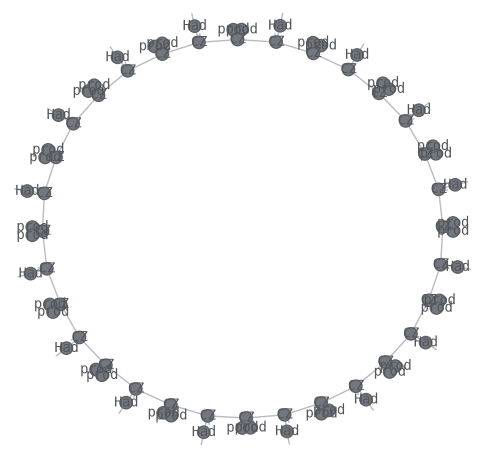

In [227]:
cluster_psi.draw()

In [228]:
results = find_invariants_via_projectors_from_random_state(
    cluster_psi,
    domains_dict,
    jw_even=True
)

## Analyze results

In [229]:
results['left_proj_vec_results']

[np.complex128(0.24999999999999917+1.734723475976802e-18j),
 np.float64(1.0000000000000004),
 Tensor(shape=(2,), inds=('v',), tags=oset(['prod', 'CZ', 'Had', 'Z']))]

In [230]:
results['right_proj_vec_results']

[np.complex128(0.2499999999999992-8.67361737988401e-18j),
 np.float64(1.0000000000000004),
 Tensor(shape=(2,), inds=('v',), tags=oset(['prod', 'CZ', 'Had', 'Z']))]

In [231]:
results['left_proj_vec_results'][2].data

array([0.12626502, 0.05051167])

In [232]:
results['right_proj_vec_results'][2].data

array([0.11550728, 0.06126942])

In [233]:
results['cut_rho_purity']

np.complex128(0.3237641679544483-8.326672684688674e-17j)

Pretty good...

In [234]:
results['sub_cut_rho_trace']

np.complex128(1.0000000000000009-1.1102230246251563e-16j)

In [235]:
results['sub_cut_rho_purity']

np.complex128(0.3237641679544483-8.326672684688674e-17j)

In [236]:
results['cut_score']

np.complex128(0.46670493531589224+5.551115123125789e-17j)

In [237]:
results['cut_overlap']

np.float64(1.0)

In [238]:
results['defect_ops_scores'][-1]

np.float64(1.0000000000000007)

In [239]:
results['left_defect_op_invariant']

np.complex128(-0.9999999994538845+1.1102294738542342e-16j)

Not great...

In [240]:
results['right_defect_op_invariant']

np.complex128(-1.0000000000000013+1.6258662451698161e-16j)

Hm, didn't change much.

Should check projectors are actually FP even.

In [171]:
results['left_proj_vec']

Tensor(shape=(2, 2, 2, 2), inds=('k6', 'k8', 'k7', 'k9'), tags=oset(['prod', 'CZ', 'Had']))

In [172]:
v = results['left_proj_vec']

In [173]:
v

Tensor(shape=(2, 2, 2, 2), inds=('k6', 'k8', 'k7', 'k9'), tags=oset(['prod', 'CZ', 'Had']))

In [174]:
gates = [
    qu_Z.reindex({'k': f'k{i}', 'b': f'b{i}'})
    for i in [7,9]
]

In [175]:
v_sym = qtn.TensorNetwork(
    [*gates, v.reindex({f'k{i}': f'b{i}' for i in [7,9]})]
)

In [176]:
(v & v.conj()).contract()

np.complex128(1+0j)

In [177]:
(v_sym & v_sym.conj()).contract()

np.complex128(1+0j)

In [178]:
(v & v_sym.conj()).contract()

np.complex128(-0.35119921490828154+0j)

No, not working.

In [179]:
results['right_proj_vec']

Tensor(shape=(2, 2, 2, 2), inds=('k22', 'k24', 'k23', 'k25'), tags=oset(['prod', 'CZ', 'Had']))

In [180]:
v = results['right_proj_vec']

In [181]:
v

Tensor(shape=(2, 2, 2, 2), inds=('k22', 'k24', 'k23', 'k25'), tags=oset(['prod', 'CZ', 'Had']))

In [182]:
gates = [
    qu_Z.reindex({'k': f'k{i}', 'b': f'b{i}'})
    for i in [23,25]
]

In [183]:
v_sym = qtn.TensorNetwork(
    [*gates, v.reindex({f'k{i}': f'b{i}' for i in [23,25]})]
)

In [184]:
(v & v.conj()).contract()

np.complex128(1+0j)

In [185]:
(v_sym & v_sym.conj()).contract()

np.complex128(1+0j)

In [186]:
(v & v_sym.conj()).contract()

np.complex128(0.33104867874846267+0j)

# Debug

In [208]:
rho = (
    cluster_psi
    & cluster_psi.conj().reindex({f'k{i}': f'b{i}' for i in [6,7,8,9]})
)

In [214]:
score, v, overlap = maximize_projector_states(rho, True)

In [215]:
score

np.complex128(0.24999999999999917-8.673617379884014e-18j)

In [216]:
overlap

np.float64(1.0000000000000004)

In [217]:
v

Tensor(shape=(2, 2, 2, 2), inds=('k7', 'k9', 'k6', 'k8'), tags=oset(['Z', 'prod', 'CZ', 'Had']))

In [218]:
gates = [
    qu_Z.reindex({'k': f'k{i}', 'b': f'b{i}'})
    for i in [7,9]
]

In [219]:
v_sym = qtn.TensorNetwork(
    [*gates, v.reindex({f'k{i}': f'b{i}' for i in [7,9]})]
)

In [220]:
(v & v.conj()).contract()

np.complex128(1.0000000000000004+0j)

In [221]:
(v_sym & v_sym.conj()).contract()

np.complex128(1.0000000000000004+0j)

In [222]:
(v & v_sym.conj()).contract()

np.complex128(1.0000000000000004+0j)

For ChatGPT

In [206]:
def lanczos_iteration(rho, v, sites):
    w = (
        rho & v.reindex({f'k{i}': f'b{i}' for i in sites})
    ).contract()

    w_norm = np.sqrt((w & w.conj()).contract())

    out = w/w_norm

    return out

def multiply_state_by_jw_string(state, sites):
    gates = [
        qu_Z.reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in sites if (i%2 == 1)
    ]

    out = qtn.TensorNetwork(
        [
            *gates,
            state.reindex({f'k{i}': f'b{i}' for i in sites if (i%2 == 1)})
        ]
    )

    return out.contract()

def lanczos_iteration_jw_even(rho, v, sites):
    w = multiply_state_by_jw_string(v, sites)
    w = (v+w)/2

    w = (
        rho & w.reindex({f'k{i}': f'b{i}' for i in sites})
    ).contract()

    w = (multiply_state_by_jw_string(w, sites) + w)/2
    w_norm = np.sqrt((w & w.conj()).contract())

    out = w/w_norm

    return out

def lanczos_algorithm(rho, v, sites, num_iters=20, jw_even=False):
    update_func = lanczos_iteration_jw_even if jw_even else lanczos_iteration
    for _ in range(num_iters):
        v = update_func(rho, v, sites)

    return v

def maximize_projector_states(rho, jw_even=False):
    k_inds = [i for i in rho.outer_inds() if i.startswith('k')]
    #b_inds = [i for i in rho.inds if i.startswith('b')]

    sites = [int(s[1:]) for s in k_inds]

    v = qtn.Tensor(
        data=random_uniform_complex((2,)*len(sites)),
        inds=[f'k{i}' for i in sites]
    )

    v = lanczos_algorithm(
        rho,
        v,
        sites,
        num_iters=20,
        jw_even=jw_even
    )

    new_v = lanczos_iteration(rho, v, sites)

    overlap = np.abs((v & new_v.conj()).contract())

    score = (
        v.reindex({f'k{i}': f'b{i}' for i in sites})
        & rho
        & v.conj()
    )
    score = score.contract()


    return score, v, overlap

rho = (
    cluster_psi
    & cluster_psi.conj().reindex({f'k{i}': f'b{i}' for i in [6,7,8,9]})
)

score, v, overlap = maximize_projector_states(rho, True)

gates = [
    qu_Z.reindex({'k': f'k{i}', 'b': f'b{i}'})
    for i in [7,9]
]

v_sym = qtn.TensorNetwork(
    [*gates, v.reindex({f'k{i}': f'b{i}' for i in [7,9]})]
)

(v & v.conj()).contract()

(v_sym & v_sym.conj()).contract()

(v & v_sym.conj()).contract()

np.complex128(1+0j)

In [207]:
(v & v_sym.conj()).contract()

np.complex128(1+0j)